<a href="https://colab.research.google.com/github/fernandodeeke/can2025/blob/main/python_solver.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1></h1>
<center><h1>Análise Numérica AN0001</h1></center>
<center><h2>2026/1</h2></center>
<center><h3>Fernando Deeke Sasse</h3></center>
<center><h3>CCT - UDESC</h3></center>
<center><h2>Zeros de Funções: Comandos de Scipy</h2></center>

### 1. Comando optimize do scipy

Na prática, para resolver equações algébricas não lineares no Python, um método eficiente é usar o solver presente no pacote scipy.optimize. O método utilizado é o de [Broyden](https://en.wikipedia.org/wiki/Broyden%27s_method), que é uma generalização dos métodos de Newton-Raphson e secantes que inclui sistemas de equações.  

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import *

Suponhamos que queremos determinar as raízes reais da equação $x^5-5x^3-2x^3+x+3\sin x +1=0$.

Definimos a função

In [ ]:
def f(x):
        return x**5-5*x**3-2*x**3+x+3*np.sin(x)+1

Façamos um gráfico desta função para localizar os zeros:

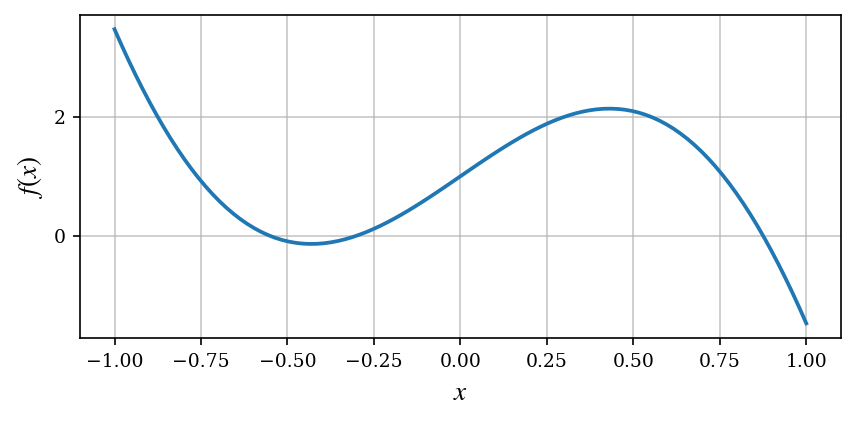

In [ ]:
plt.rcParams["text.usetex"] = False
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 13

# Plot
x = np.linspace(-1, 1, 100)

plt.figure(figsize=(6, 3), dpi=150)
plt.plot(x, f(x), lw=1.8)

plt.xlabel(r"$x$")
plt.ylabel(r"$f(x)$")

plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

plt.grid(alpha=0.7)
plt.tight_layout()
plt.show()


Vemos que há raízes próximas a -0.5, -0.25 e 1.0. Usando estes pontos como pontos iniciais, e definindo uma tolerância de $10^{-14}$ para o erro, procedemos da seguinte maneira:

In [ ]:
r = broyden1(f, [-0.5,-0.25,1], f_tol=1e-14)
r

array([-0.55159914, -0.30000465,  0.87510624])

Verifiquemos a acurácia dos resultados:

In [ ]:
f(r[[0 ,1 ,2]])


array([ 2.22044605e-16, -1.99840144e-15,  7.99360578e-15])

Podemos simplesmente usar o comando fsolve

In [ ]:
r2=fsolve(f,[-0.5, -0.25,1])
print(r2)

[-0.55159914 -0.30000465  0.87510624]


Podemos também usar este comando para encontrar raízes complexas. Por exemplo, seja $f(t) =t\cos(t^2)+1=0$:

In [ ]:
def g(t):
        return t*cos(t**2)+1

Além das raízes reais podemos ter também raízes complexas. De fato, para equações algébricas gerais há um número infinito delas. Determinemos algumas:

In [ ]:
from cmath import *

In [ ]:
z=complex(1,1)
rc1=broyden1(g,[z], f_tol=1e-14)
rc1

/tmp/ipykernel_4858/2474771132.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return t*cos(t**2)+1


array([-0.8760649+0.36355277j])

In [ ]:
z=complex(1,-2)
rc2=broyden1(g,[z], f_tol=1e-14)
rc2

/tmp/ipykernel_4858/2474771132.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return t*cos(t**2)+1


array([0.25677608-1.32323822j])

In [ ]:
z=complex(1,-1)
rc3=broyden1(g,[z], f_tol=1e-14)
rc3

/tmp/ipykernel_4858/2474771132.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return t*cos(t**2)+1


array([-0.8760649-0.36355277j])

De fato, podemos verificar que estes números satisfazem a equação:

In [ ]:
g(rc1)

array([0.+0.j])

In [ ]:
g(rc2)

array([0.+1.94289029e-16j])

In [ ]:
g(rc3)

array([0.+0.j])

### 2. Determinação de máximos e mínimos

<bf>1.</bf> Seja a função $f(x)=x^2+x\sin(x^3)+3x-10$. <br>
(i) Faça um gráfico desta função. <br>
(ii) Determine todas as raízes reais positivas, usando o solver do scipy, com uma tolerância de intervalo $\epsilon = 10^{-10}$.<br>
(iii) Use os métodos do scipy com tolerância de intervalo $\epsilon = 10^{-10}$ para determinar os extremos relativos (especificando $x$ e $f(x)$) de $f(x)$ no intervalo $[1.5, 2.2]$.

In [ ]:
from matplotlib.pyplot import *
from scipy.optimize import *
from numpy import *

Para fazer o gráfico definimos antes a função:

In [ ]:
def f(x):
    return  x**2-x*sin(x**3)+3*x-10

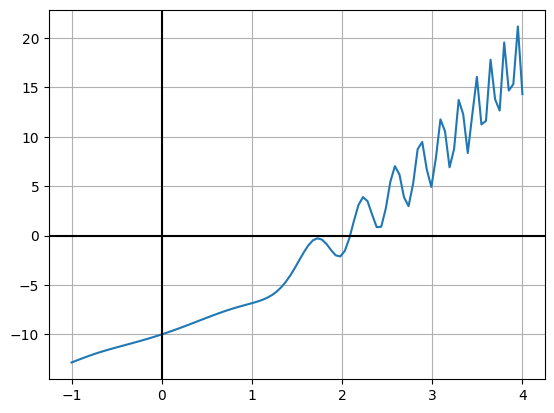

In [ ]:
x=linspace(-1,4,100)
fig, ax = subplots()
ax.grid(True, which='both')
ax.plot(x, f(x))
ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')

(ii) Certamente temos uma raiz real nas proximidade de 2.0:

In [ ]:
r=broyden1(f,[2.0],f_tol=1e-10)
print(r)

[2.08910489]


(iii) Para calcular os extremos no intervalo $[1.5,2.2]$ devemos calcular a derivada da função:

In [ ]:
from sympy import *

In [ ]:
t=symbols('t')

In [ ]:
f= Lambda(t, t**2-t*sin(t**3)+3*t-10)
f(t)

t**2 - t*sin(t**3) + 3*t - 10

In [ ]:
df=diff(f(t),t)
df

-3*t**3*cos(t**3) + 2*t - sin(t**3) + 3

Para fazer o gráfico desta função devemos definir esta derivada como uma função do simpy:

In [ ]:
Df= Lambda(t, df)
Df(t)

-3*t**3*cos(t**3) + 2*t - sin(t**3) + 3

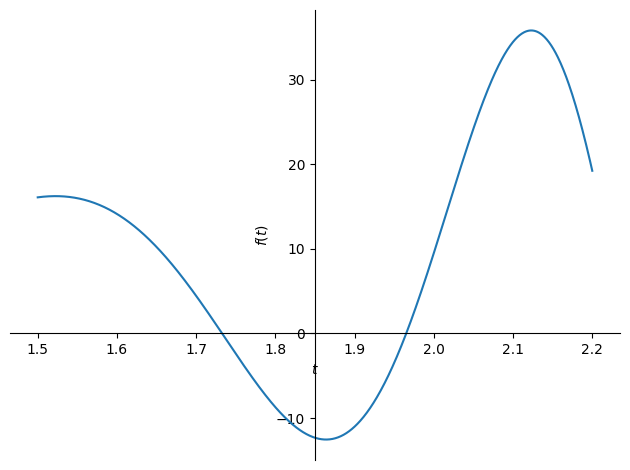

In [ ]:
plot(Df(t),(t,1.5,2.2))

Temos duas raízes neste intervalo. Para usar o comando broyden1 devemos redefinir a derivada como função do numpy. Para isso devemos recomeçar o kernel e copiar a expressão para a derivada, repetindo depois o procedimento anteriormente descrito:

In [ ]:
#restart kernel

In [ ]:
from matplotlib.pyplot import *
from scipy.optimize import *
from numpy import *

In [ ]:
def df(t):
        return  -3*t**2*cos(t**3)+2*t-sin(t**3)+3

In [ ]:
r = broyden1(df, [1.75,1.95], f_tol=1e-10)
r

array([1.77361952, 1.93895455])

Estes são os valores de $x$ onde $f(x)$ tem extremos relativos no intervalo $[1.5, 2.2]$. Vejamos agora o valor de $f(x)$ nestes pontos:

In [ ]:
 def f(x):
        return  x**2-x*sin(x**3)+3*x-10

In [ ]:
f(r)

array([-0.38558515, -2.06183806])

### 3. Exercícios

1. Usando o solver no scipy, determine as raízes reais de $f(x)=x^2+x\cos(x)+x-1$, assim como o ponto de mínimo $x^*$ e $f(x^*)$. Use uma tolerância $\epsilon=10^{-11}$.

2. Resolva o problema apresentado em sala

In [ ]:
from matplotlib.pyplot import *
from scipy.optimize import *
from numpy import *

In [ ]:
rho = 1.23
mu = 1.79*10**(-5)
D = 0.005
V = 40
epsilon = 0.0015
Re = rho*V*D/mu

In [ ]:
def g(f):
        return  1/sqrt(f)+2*log10(epsilon/(3.7*D)+2.51/(Re*sqrt(f)))

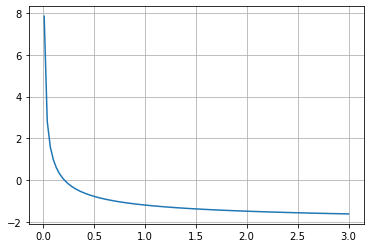

In [ ]:
f=linspace(0.01,3,100)
fig, ax = subplots()
ax.grid(True, which='both')
ax.plot(f, g(f))
#ax.axhline(y=0, color='k')
#ax.axvline(x=0, color='k')

In [ ]:
r = broyden1(g, [0.2], f_tol=1e-10)
r

array([0.210824])

In [ ]:
g(r)

array([4.76818585e-12])